# Speculative Decoding - 실습 코드 2: Speculative Decoding 원리 구현 (순수 PyTorch)

- Tutorial ID: `expand-speculative-decoding`
- Tutorial: Speculative Decoding
- Section ID: `expand-speculative-decoding-code-2`
- Section: 실습 코드 2: Speculative Decoding 원리 구현 (순수 PyTorch)

> 이 노트북은 Speculative Decoding을 처음 공부하는 분들을 위해 모든 단계에
> 상세한 설명과 작은 예제를 덧붙인 버전입니다. 새로운 개념이 나올 때마다
> 먼저 말로 풀어 설명하고, 아주 작은 예제로 직접 실행해 확인한 뒤에
> 전체 알고리즘으로 합치는 순서로 구성했습니다.

In [1]:
# ============================================================
# 코드 읽는 법 - 실습 코드 2: Speculative Decoding 원리 구현 (순수 PyTorch)
#
# 이 노트북은 "정답 코드를 한 번 실행"하는 용도가 아니라, Speculative
# Decoding의 수학적 아이디어가 실제 텐서 연산으로 어떻게 구현되는지
# 한 걸음씩 따라가며 이해하기 위한 실습 노트입니다.
#
# 학습 목표:
#   1) logit이 확률분포로 바뀌는 과정과 temperature/top-k/top-p의 효과 이해
#   2) 자기회귀 디코딩이 왜 느린지, Speculative Decoding이 왜 빠른지 이해
#   3) Draft(제안) -> Target(병렬 검증) -> Accept/Reject(수락/거절) 3단계 흐름 이해
#   4) "거절되면 왜 target 분포에서 그냥 재샘플링하면 안 되는가?"
#      (잔여분포 / residual distribution)의 필요성을 직접 실험으로 확인
#   5) Speculative Decoding이 품질 손실 없이("무손실") target 모델과
#      동일한 분포에서 토큰을 생성한다는 것을 소규모 실험으로 검증
#
# 읽는 순서:
#   1) Step 0: 아주 작은 예제로 temperature/top-k/top-p 감을 잡습니다.
#   2) Step 1~4: Draft 생성 -> Target 병렬 검증 -> 수락/거절 -> 보너스 토큰
#      순서로, 각 단계를 "혼자 떼어낸 작은 코드"로 먼저 실습한 뒤
#      마지막에 전체를 합친 speculative_decode() 함수를 봅니다.
#   3) 마지막에는 실제 속도 비교와, "무손실"이 맞는지 통계적으로
#      확인하는 검증 실험까지 진행합니다.
#
# 주의:
#   - 여기 등장하는 TinyLM은 학습되지 않은(무작위 가중치) 모델입니다.
#     "그럴듯한 문장을 생성"하는 것이 목적이 아니라 알고리즘의 shape과
#     동작 흐름을 보는 것이 목적이므로, 출력 토큰 자체의 의미는 없습니다.
#   - 숫자 하나하나를 외우기보다 "shape 변화"와 "정보가 이동하는 방향",
#     그리고 "확률이 어떻게 다뤄지는지"를 눈으로 좇아가 보세요.
# ============================================================

## 왜 Speculative Decoding이 필요한가?

큰 언어모델(LLM)이 문장을 생성할 때는 **토큰을 한 번에 하나씩** 만듭니다.
"오늘 날씨가" 라는 프롬프트 다음에 "좋다"를 만들려면 모델을 한 번
실행해야 하고, 그다음 "좋다" 뒤에 "."을 만들려면 모델을 **또** 실행해야
합니다. 즉, 토큰 100개를 생성하려면 모델을 100번 실행해야 합니다.
이것을 **자기회귀(autoregressive) 디코딩**이라고 부릅니다.

문제는 이 100번의 실행이 GPU 입장에서 보면 꽤 비효율적이라는 점입니다.

- 토큰 1개를 만들기 위해서도 모델의 파라미터(수십억~수천억 개)를
  전부 GPU 메모리에서 읽어와야 합니다.
- 그런데 실제로 계산하는 양(토큰 1개 분량의 연산)은 GPU가 한 번에
  처리할 수 있는 용량에 비하면 아주 작습니다.
- 결과적으로 GPU는 "계산"보다 "메모리에서 가중치를 읽어오는 것"을
  기다리는 시간이 더 깁니다. 이런 상황을 **메모리 대역폭에 의해
  병목이 걸린다(memory-bound)**고 표현합니다.

반면, 트랜스포머는 **이미 정해진 시퀀스를 평가(evaluate)하는 것**은
토큰 개수가 늘어나도 시간이 크게 늘지 않습니다. 즉, "토큰 5개짜리
문장의 각 위치에서 다음에 뭐가 올지"를 계산하는 것은, "토큰 1개짜리
입력의 다음 토큰을 예측하는 것"과 비교해 걸리는 시간이 거의 비슷합니다
(가중치를 읽어오는 비용은 어차피 1번뿐이니까요). 다만 이게 가능하려면
시퀀스 전체가 **이미 정해져** 있어야 합니다 - 순서대로 하나씩 "다음엔
뭘 넣을지" 새로 정하면서 만들어가는 것(생성/샘플링)은 여전히 순차적일
수밖에 없습니다.

**Speculative Decoding의 아이디어**는 바로 이 성질을 이용합니다.

> 작고 빠른 모델(Draft)이 "다음에 나올 것 같은 토큰 여러 개"를 먼저
> 빠르게 추측해 시퀀스를 미리 확정해두면, 크고 느린 모델(Target)은
> 그 추측들을 한꺼번에(병렬로) 검증만 하면 됩니다. 추측이 맞았으면
> 그대로 채택하고, 틀렸으면 그 지점부터 다시 정확하게 뽑습니다.
> 이렇게 하면 Target 모델을 호출하는 횟수를 크게 줄이면서도,
> **최종 결과물의 확률분포는 Target 모델 혼자 생성한 것과 완전히
> 동일**하게 유지할 수 있습니다.

이번 실습에서는 이 알고리즘을 순수 PyTorch로 한 줄씩 직접 구현하면서
"왜 빠른가"와 "왜 품질 손실이 없는가"를 모두 확인해 보겠습니다.

## 비유로 먼저 이해하기: 인턴과 시니어 개발자

- **Draft 모델 = 인턴**: 빠르지만 가끔 실수하는 주니어. 코드를 빠르게 여러 줄 작성합니다.
- **Target 모델 = 시니어 개발자**: 느리지만 정확한 시니어. 한 줄씩 직접 짜면 정확하지만 느립니다.

시니어가 인턴이 짠 코드 5줄을 **한 번에 훑어보고(=병렬 검증)**:

- 인턴이 짠 부분이 자기 생각과 같거나 더 낫다고 판단하면 그대로 **승인**합니다.
- 생각과 다른 부분이 나오면 그 줄부터는 **직접 고쳐 쓰고**, 그 뒤에 인턴이
  이어서 짠 줄들은 (아직 검토도 못했으니) 이번 라운드에서는 버리고
  다음 라운드에서 다시 받습니다.

시니어가 코드를 한 줄씩 처음부터 다 짜는 것보다, 인턴이 초안을 주고
시니어가 "훑어보며 승인/수정"하는 쪽이 전체적으로 더 빠릅니다 -
**최종 코드 품질이 시니어가 전부 직접 짠 것과 동일하다**는 전제하에서
말이죠. Speculative Decoding이 수학적으로 보장하는 것이 바로 이
"최종 품질이 동일하다"는 부분이고, 뒤에서 그 이유를 직접 실험으로
확인해 보겠습니다.

## Step 0. 준비운동: logit -> 확률분포 (temperature / top-k / top-p)

본격적인 구현에 들어가기 전에, 뒤에서 계속 쓰일 개념을 먼저 짚고
넘어갑니다.

언어모델은 다음 토큰에 대해 바로 확률을 내놓지 않고, **logit**이라는
정규화되지 않은 점수(아무 실수 값이나 가능)를 먼저 출력합니다. 이
logit을 "합이 1인 확률분포"로 바꿔주는 과정에는 몇 가지 조절 방법이
있습니다.

- **softmax**: logit을 지수함수에 넣고 정규화해서 확률로 바꾸는 기본 변환.
- **temperature(온도)**: softmax에 넣기 전에 logit을 온도 값으로 나눕니다.
  - `T < 1` : 값들의 차이가 더 벌어짐 -> 분포가 뾰족해짐 (확신에 찬/결정적인 선택)
  - `T > 1` : 값들의 차이가 완만해짐 -> 분포가 평평해짐 (다양하고 무작위적인 선택)
  - `T = 1` : 원래 softmax와 동일
- **top-k**: 확률이 가장 높은 k개 토큰만 후보로 남기고 나머지는 제외
- **top-p (nucleus sampling)**: 확률이 높은 순서대로 더해가다가, 누적
  확률이 p를 넘는 순간까지만 후보로 남김 (후보 개수가 상황에 따라 유동적)

Speculative Decoding에서 Draft 모델이 토큰을 "샘플링"할 때 바로 이
temperature가 사용됩니다. (검증 단계에서는 Draft가 **정확히 어떤
확률로** 그 토큰을 뽑았는지가 중요한데, top-k/top-p처럼 후보 자체를
잘라내 버리면 검증에 필요한 확률 계산이 더 복잡해집니다. 그래서 이번
실습에서는 이해를 돕기 위해 Draft/Target 모두 temperature만 사용하는
기본 버전으로 구현합니다.)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import time
import warnings

# PyTorch 내부에서 나오는, 알고리즘과 무관한 자잘한 경고 메시지를 숨겨서
# 출력을 깔끔하게 유지합니다. 궁금하다면 아래 줄을 주석 처리하고 다시
# 실행해서 어떤 경고들이 뜨는지 직접 확인해봐도 좋습니다.
warnings.filterwarnings("ignore")

# 실습 결과를 매번 똑같이 재현할 수 있도록 난수 시드를 고정합니다.
# (고정하지 않으면 샘플링 단계 때문에 실행할 때마다 결과 숫자가 달라집니다.)
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)
device_msg = "cuda" if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", device_msg, "(이 실습은 모델이 아주 작아서 CPU로도 충분히 빠릅니다)")


# ── 그래프에 한글이 깨지지 않도록 폰트를 설정 (알고리즘 내용과는 무관한 선택 사항) ──
def _setup_korean_font():
    keywords = ("nanum", "cjk", "malgun", "gothic", "applegothic", "batang", "gulim")
    for f in fm.fontManager.ttflist:
        if any(k in f.name.lower() for k in keywords):
            return f.name
    for path in fm.findSystemFonts():
        if any(k in path.lower() for k in ("nanum", "cjk", "malgun", "gothic")):
            try:
                fm.fontManager.addfont(path)
            except Exception:
                pass
    for f in fm.fontManager.ttflist:
        if any(k in f.name.lower() for k in keywords):
            return f.name
    try:
        import subprocess
        subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"],
                        check=True, timeout=60,
                        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for path in fm.findSystemFonts():
            if "nanum" in path.lower():
                fm.fontManager.addfont(path)
        for f in fm.fontManager.ttflist:
            if "nanum" in f.name.lower():
                return f.name
    except Exception:
        pass
    return None


_korean_font = _setup_korean_font()
if _korean_font:
    plt.rcParams["font.family"] = _korean_font
plt.rcParams["axes.unicode_minus"] = False
print("그래프용 한글 폰트:", _korean_font if _korean_font else
      "찾지 못함 (그래프의 한글 라벨이 깨질 수 있습니다. 시스템에 한글 폰트를 설치해보세요)")

PyTorch 버전: 2.12.1+cu130
사용 디바이스: cpu (이 실습은 모델이 아주 작아서 CPU로도 충분히 빠릅니다)
그래프용 한글 폰트: Noto Sans CJK JP

[temperature = 1.0 (원본)]
  토큰0   : 0.192 #########
  토큰1   : 0.071 ###
  토큰2   : 0.029 #
  토큰3   : 0.010 
  토큰4   : 0.523 ##########################
  토큰5   : 0.043 ##
  토큰6   : 0.016 
  토큰7   : 0.117 #####

[temperature = 0.3 (뾰족해짐)]
  토큰0   : 0.034 #
  토큰1   : 0.001 
  토큰2   : 0.000 
  토큰3   : 0.000 
  토큰4   : 0.958 ###############################################
  토큰5   : 0.000 
  토큰6   : 0.000 
  토큰7   : 0.006 

[temperature = 2.0 (평평해짐)]
  토큰0   : 0.185 #########
  토큰1   : 0.112 #####
  토큰2   : 0.072 ###
  토큰3   : 0.041 ##
  토큰4   : 0.305 ###############
  토큰5   : 0.087 ####
  토큰6   : 0.053 ##
  토큰7   : 0.144 #######

[top-k = 3 (확률 상위 3개만 남김)]
  토큰0   : 0.231 ###########
  토큰1   : 0.000 
  토큰2   : 0.000 
  토큰3   : 0.000 
  토큰4   : 0.629 ###############################
  토큰5   : 0.000 
  토큰6   : 0.000 
  토큰7   : 0.140 #######

[top-p = 0.8 (누적확률 80%까지만 남김)]
  토큰0   : 0.231 ###########
  토큰1   : 0.000 
  토큰2   : 0.000 
  토큰3   : 0.000 
  토큰4   : 0.629 ##############################

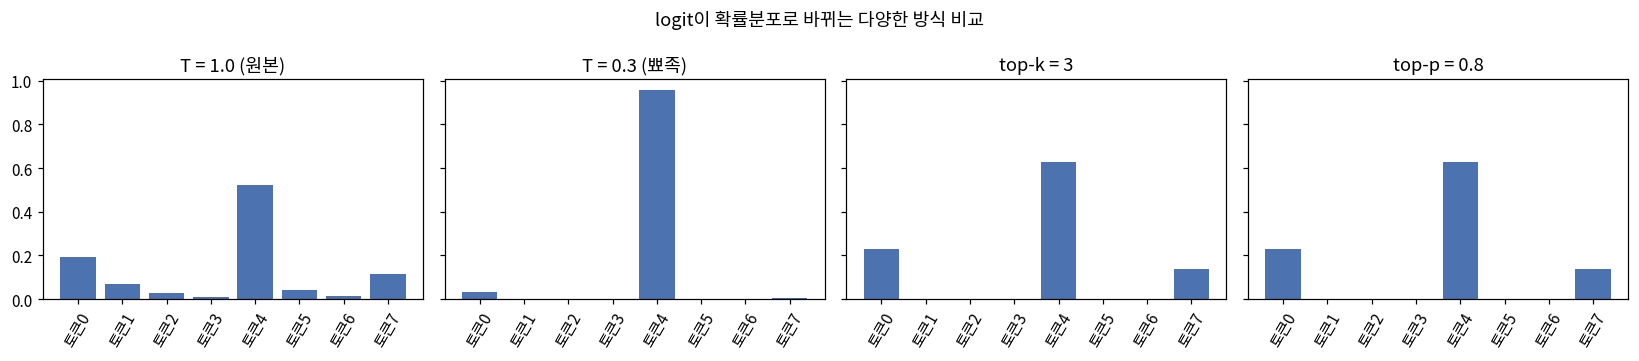

In [3]:
# ------------------------------------------------------------
# 아주 작은 "가짜 logit"으로 temperature / top-k / top-p 실험
# ------------------------------------------------------------
# 실제 언어모델은 수만 개의 토큰에 대해 logit을 출력하지만, 여기서는
# 개념을 눈으로 보기 쉽도록 8개 토큰짜리 장난감 예시를 사용합니다.

torch.manual_seed(0)
vocab_demo = [f"토큰{i}" for i in range(8)]
logits_demo = torch.tensor([2.0, 1.0, 0.1, -1.0, 3.0, 0.5, -0.5, 1.5])


def show_distribution(probs, title):
    """확률분포를 표로 보여주는 헬퍼 함수 (막대는 텍스트로 대략적인 크기만 표시)"""
    print(f"[{title}]")
    for tok, p in zip(vocab_demo, probs.tolist()):
        bar = "#" * int(p * 50)
        print(f"  {tok:6s}: {p:.3f} {bar}")
    print()


def top_k_filter(probs, k):
    """확률이 가장 높은 k개만 남기고 나머지는 0으로 만든 뒤 다시 정규화"""
    probs = probs.clone()
    _, top_indices = torch.topk(probs, k)
    mask = torch.zeros_like(probs, dtype=torch.bool)
    mask[top_indices] = True
    probs[~mask] = 0.0
    return probs / probs.sum()


def top_p_filter(probs, p):
    """누적 확률이 p 이상이 되는 최소 개수의 토큰만 남기고 나머지는 제거 (nucleus sampling)"""
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    # 누적확률이 아직 p 미만인 토큰 개수 + 1(=p를 처음 넘기는 토큰까지 포함)
    n_keep = int((cumulative < p).sum().item()) + 1
    n_keep = min(n_keep, probs.numel())
    keep_idx = sorted_idx[:n_keep]
    mask = torch.zeros_like(probs, dtype=torch.bool)
    mask[keep_idx] = True
    filtered = torch.where(mask, probs, torch.zeros_like(probs))
    return filtered / filtered.sum()


# (1) 기본 softmax (temperature = 1)
probs_raw = F.softmax(logits_demo, dim=-1)
show_distribution(probs_raw, "temperature = 1.0 (원본)")

# (2) temperature를 낮추면(<1): 분포가 뾰족해짐 (보수적/결정적)
probs_low_t = F.softmax(logits_demo / 0.3, dim=-1)
show_distribution(probs_low_t, "temperature = 0.3 (뾰족해짐)")

# (3) temperature를 높이면(>1): 분포가 평평해짐 (다양함/무작위적)
probs_high_t = F.softmax(logits_demo / 2.0, dim=-1)
show_distribution(probs_high_t, "temperature = 2.0 (평평해짐)")

# (4) top-k: 상위 3개만 남김
probs_topk = top_k_filter(probs_raw, k=3)
show_distribution(probs_topk, "top-k = 3 (확률 상위 3개만 남김)")

# (5) top-p: 누적확률 80%까지만 남김
probs_topp = top_p_filter(probs_raw, p=0.8)
show_distribution(probs_topp, "top-p = 0.8 (누적확률 80%까지만 남김)")

# 네 가지 분포를 막대그래프로 한눈에 비교
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3), sharey=True)
for ax, (probs, title) in zip(axes, [
    (probs_raw, "T = 1.0 (원본)"),
    (probs_low_t, "T = 0.3 (뾰족)"),
    (probs_topk, "top-k = 3"),
    (probs_topp, "top-p = 0.8"),
]):
    ax.bar(vocab_demo, probs.tolist(), color="#4C72B0")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=60)
fig.suptitle("logit이 확률분포로 바뀌는 다양한 방식 비교")
plt.tight_layout()
plt.show()

## 자기회귀(Autoregressive) 디코딩 복습

토큰을 하나 생성할 때마다 지금까지의 전체 시퀀스를 모델에 다시 넣어서
"다음 토큰 하나"만 얻어내는 것이 표준적인 생성 방식입니다.

```
프롬프트: [w1, w2, w3]

1번째 forward:  [w1, w2, w3]              -> 다음 토큰 예측 -> w4
2번째 forward:  [w1, w2, w3, w4]          -> 다음 토큰 예측 -> w5
3번째 forward:  [w1, w2, w3, w4, w5]      -> 다음 토큰 예측 -> w6
...
```

토큰 N개를 생성하려면 forward를 **N번** 순서대로 호출해야 하고, 이전
호출의 결과(새 토큰)가 있어야 다음 호출을 시작할 수 있습니다(병렬화
불가능). 이 "순차성"이 바로 자기회귀 디코딩이 느린 근본 원인입니다.

## Speculative Decoding 알고리즘 개요

아래 3단계를 하나의 "라운드"로 반복합니다.

1. **Draft(제안)**: 작은 Draft 모델이 지금까지의 시퀀스 뒤에 이어질
   토큰을 K개, 자기회귀 방식으로 빠르게 만듭니다. (여전히 순차적이지만
   모델이 작아서 훨씬 빠릅니다.)
2. **Verify(병렬 검증)**: 큰 Target 모델에 "지금까지의 시퀀스 + Draft가
   제안한 K개 토큰"을 **한 번에** 통과시켜, K+1개 위치 각각에서 Target
   이라면 어떤 확률을 줬을지 한꺼번에 얻습니다.
3. **Accept/Reject(수락/거절)**: 제안된 토큰을 앞에서부터 하나씩
   검사하면서, Target이 그 토큰에 얼마나 "동의"하는지에 비례해
   확률적으로 수락합니다. 처음으로 거절이 발생하면 그 자리에서 멈추고,
   그 위치의 토큰만 Target 기준으로 다시 뽑은 뒤 라운드를 종료합니다.
   만약 K개가 전부 수락되면, 이미 계산해둔 Target의 다음 예측에서
   보너스 토큰을 하나 더 받습니다.

아래에서 이 3단계를 하나씩 작은 코드로 직접 실습해 본 뒤, 마지막에
전체를 하나의 함수로 합칩니다.

## 실습에 사용할 아주 작은 언어모델 (TinyLM)

Draft와 Target 둘 다 아래의 동일한 `TinyLM` 클래스를 사용하고, 크기
(레이어 수, 차원 수)만 다르게 해서 "작은 모델 vs 큰 모델" 상황을
흉내 냅니다.

구성 요소:
1. **토큰 임베딩(embed)**: 정수 토큰 ID -> 벡터
2. **위치 임베딩(pos_embed)**: 각 토큰이 시퀀스에서 몇 번째인지 알려주는
   벡터. Self-Attention 연산 자체는 순서를 모르기 때문에, 위치 정보를
   별도로 더해줘야 "첫 번째 토큰"과 "다섯 번째 토큰"을 구분할 수 있습니다.
3. **Transformer 인코더 레이어 여러 개**: 문맥을 반영해 표현을 갱신
4. **head**: 마지막 벡터를 다시 vocab_size 크기의 logit으로 변환

한 가지 중요한 제약이 있습니다: 언어모델은 **미래 토큰을 훔쳐보면
안 됩니다.** i번째 위치는 0~i번째 토큰까지만 보고 다음 토큰을
예측해야 합니다(이것이 "자기회귀"라는 말의 의미이기도 합니다). 이를
위해 대각선 위쪽(미래 위치)을 -inf로 채운 **causal mask(인과 마스크)**를
만들어 Attention 연산에 전달합니다. 이 마스크가 없으면 모델이 미래
토큰의 정보를 미리 보고 예측하게 되어, 뒤에서 다룰 "Draft가 예측한
분포"와 "Target이 같은 위치에서 예측한 분포"를 비교하는 것 자체가
의미 없어집니다.

한 가지 더 신경 써야 할 것이 있습니다: `nn.TransformerEncoderLayer`는
기본적으로 **dropout**(학습 중 일부 뉴런을 무작위로 꺼서 과적합을
막는 기법)이 켜져 있고, PyTorch의 `nn.Module`은 만들어질 때 기본값이
"학습 모드"입니다. 학습 모드에서는 **완전히 같은 입력을 두 번 넣어도
dropout이 매번 다른 무작위 값을 꺼버리기 때문에 출력이 매번 달라집니다.**
Speculative Decoding은 "Target이 이 위치에서 내놓는 예측"이 **항상
똑같다**는 전제 위에 서 있으므로(같은 입력에 다른 출력이 나오면
비교 자체가 무의미해집니다), 모델을 만든 뒤에는 반드시
**`model.eval()`**을 호출해서 dropout을 꺼주어야 합니다. 이는 이
알고리즘만의 특수한 사정이 아니라, **추론(inference)에는 항상
`.eval()`을 사용한다**는 PyTorch의 일반적인 규칙이기도 합니다.

> 이 모델은 학습되지 않은 무작위 가중치 상태입니다. 실제로 그럴듯한
> 문장을 만들지는 못하지만, Speculative Decoding 알고리즘 자체는
> 모델이 무엇을 예측하든 상관없이 동일하게 동작하므로, 학습 없이도
> 알고리즘의 구조를 관찰하는 데는 전혀 문제가 없습니다.

In [4]:
class TinyLM(nn.Module):
    """
    아주 작은 Transformer 기반 언어모델.
    Draft/Target 모두 이 클래스를 쓰고, 크기(파라미터 수)만 다르게 만듭니다.
    """

    def __init__(self, vocab_size=1000, d_model=128, n_layers=2, nhead=4, max_len=512):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                batch_first=True,   # 입력 shape을 (batch, seq_len, d_model) 순서로 사용
            ) for _ in range(n_layers)
        ])
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        """
        x: (batch, seq_len) 정수 토큰 ID 텐서
        반환: (batch, seq_len, vocab_size) logit 텐서
        """
        batch_size, seq_len = x.shape

        # (batch, seq_len) -> (batch, seq_len, d_model)
        # 토큰 임베딩 + 위치 임베딩을 더해서 "무엇"인지와 "몇 번째"인지를 함께 표현
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)
        h = self.embed(x) + self.pos_embed(positions)

        # causal mask: (seq_len, seq_len) 크기, 대각선 위쪽(미래)이 -inf
        # 예) seq_len=4 이면
        #   [[  0, -inf, -inf, -inf],
        #    [  0,    0, -inf, -inf],
        #    [  0,    0,    0, -inf],
        #    [  0,    0,    0,    0]]
        # i번째 행(=i번째 토큰의 attention)은 자기 자신을 포함해 0~i번째
        # 열(과거 토큰)만 -inf가 아니므로, i번째 토큰은 미래를 보지 못합니다.
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)

        for layer in self.layers:
            h = layer(h, src_mask=causal_mask)

        return self.head(h)   # (batch, seq_len, vocab_size)

    @torch.no_grad()
    def get_logprobs(self, x):
        """
        시퀀스의 각 위치에서 "다음 토큰"에 대한 로그 확률을 반환합니다.

        @torch.no_grad(): 생성(추론) 단계에서는 역전파(학습)가 필요
        없으므로 그래디언트 계산을 꺼서 메모리와 연산을 아낍니다.
        """
        logits = self.forward(x)
        return F.log_softmax(logits, dim=-1)

### 실습: 모델에 입력을 넣고 shape 흐름 확인하기

숫자 하나하나보다는 "텐서의 shape이 어떻게 바뀌는지"에 집중해서
봐 주세요. `forward()`와 `get_logprobs()` 모두 입력과 동일한
`(batch, seq_len)` 자리에 `vocab_size` 차원이 새로 붙어서
`(batch, seq_len, vocab_size)`가 되는 것을 확인할 수 있습니다.

In [5]:
torch.manual_seed(1)
demo_model = TinyLM(vocab_size=50, d_model=16, n_layers=1, nhead=2)
demo_model.eval()   # 추론 모드로 전환: dropout을 끄고, 항상 같은 입력엔 같은 출력이 나오게 함

batch, seq_len = 1, 4
sample_input = torch.randint(0, 50, (batch, seq_len))
print("입력 토큰 ID:", sample_input.tolist())
print("입력 shape:  ", tuple(sample_input.shape), "= (batch=1, seq_len=4)")

logits = demo_model(sample_input)
print("\nforward() 출력(logits) shape:", tuple(logits.shape), "= (batch, seq_len, vocab_size)")

logprobs = demo_model.get_logprobs(sample_input)
print("get_logprobs() 출력 shape:   ", tuple(logprobs.shape), "(logits와 동일한 shape)")

print("\n마지막 위치(=다음 토큰 예측)의 로그확률 중 상위 5개 토큰:")
last_logprobs = logprobs[0, -1, :]   # (vocab_size,)
top5 = torch.topk(last_logprobs, 5)
top5_probs = torch.exp(top5.values)
for rank, (logp, prob, idx) in enumerate(zip(top5.values.tolist(), top5_probs.tolist(), top5.indices.tolist()), 1):
    print(f"  {rank}위: 토큰ID {idx:3d}  logprob={logp:.3f}  prob={prob:.4f}")

입력 토큰 ID: [[44, 24, 29, 26]]
입력 shape:   (1, 4) = (batch=1, seq_len=4)

forward() 출력(logits) shape: (1, 4, 50) = (batch, seq_len, vocab_size)
get_logprobs() 출력 shape:    (1, 4, 50) (logits와 동일한 shape)

마지막 위치(=다음 토큰 예측)의 로그확률 중 상위 5개 토큰:
  1위: 토큰ID  48  logprob=-2.155  prob=0.1159
  2위: 토큰ID  28  logprob=-3.293  prob=0.0371
  3위: 토큰ID  26  logprob=-3.301  prob=0.0369
  4위: 토큰ID  14  logprob=-3.344  prob=0.0353
  5위: 토큰ID  21  logprob=-3.455  prob=0.0316

## Step 1. Draft: 작은 모델이 K개 토큰을 미리 제안하기

Draft 모델은 지금까지 만들어진 시퀀스 뒤에, 평소 자기회귀 디코딩과
똑같은 방식으로 토큰을 하나씩 이어 붙입니다. 다른 점은, 이후 검증
단계에서 "Draft가 이 토큰을 얼마나 확신했는지(확률)"가 반드시
필요하기 때문에, 토큰뿐 아니라 **그 순간 Draft가 사용한 확률분포
전체도 함께 저장**해 둔다는 점입니다. (뽑힌 토큰 하나의 확률값만
저장하면 안 되는 이유는 Step 3에서 자세히 다룹니다.)

In [6]:
def draft_propose(draft_model, prefix, k, temperature=1.0, verbose=True):
    """
    draft_model이 prefix 뒤에 이어질 토큰을 k개, 한 번에 하나씩(자기회귀) 생성합니다.

    반환값:
      draft_tokens : 생성된 토큰들의 리스트 (각 원소는 shape (batch, 1))
      draft_dists  : 그 토큰을 뽑을 때 사용한 "전체 확률분포" 리스트
                     (각 원소는 shape (batch, vocab_size))

    주의: 단순히 "뽑힌 토큰의 확률(스칼라)"만 저장하면 안 됩니다! 뒤에서
    거절 시 잔여분포 residual(x) = max(0, p(x) - q(x))를 계산하려면
    어휘 전체에 대한 draft의 확률분포 q(.)가 통째로 필요합니다. 스칼라
    하나(q(뽑힌 토큰))만 있으면 이 뺄셈을 벡터 단위로 할 수 없습니다.
    """
    draft_tokens = []
    draft_dists = []
    current = prefix

    for step in range(k):
        logprobs = draft_model.get_logprobs(current)   # (batch, seq_len, vocab)
        next_logprob = logprobs[:, -1, :]                # 마지막 위치 = "다음 토큰" 예측 (이미 로그확률)

        probs = F.softmax(next_logprob / temperature, dim=-1)   # 실제로 샘플링에 쓰는 전체 분포 q(.)
        next_token = torch.multinomial(probs, num_samples=1)     # (batch, 1) 샘플링

        if verbose:
            # gather: next_token 인덱스에 해당하는 값만 뽑아옵니다.
            # 예) probs가 [[0.1, 0.7, 0.2]] 이고 next_token이 [[1]]이면 gather 결과는 [[0.7]]
            token_prob = probs.gather(1, next_token)
            print(f"  [draft {step + 1}/{k}] 새 토큰ID={next_token.item():4d}  "
                  f"draft가 매긴 확률={token_prob.item():.4f}")

        draft_tokens.append(next_token)
        draft_dists.append(probs)
        current = torch.cat([current, next_token], dim=1)

    return draft_tokens, draft_dists


torch.manual_seed(2)
mini_draft = TinyLM(vocab_size=50, d_model=16, n_layers=1, nhead=2)
mini_draft.eval()   # 추론 모드로 전환 (dropout 끄기)
mini_prefix = torch.randint(0, 50, (1, 3))
print("prefix:", mini_prefix.tolist())
print("Draft 모델이 5개 토큰을 순서대로(자기회귀) 생성합니다:")
draft_tokens_demo, draft_dists_demo = draft_propose(mini_draft, mini_prefix, k=5)

prefix: [[13, 23, 43]]
Draft 모델이 5개 토큰을 순서대로(자기회귀) 생성합니다:
  [draft 1/5] 새 토큰ID=  28  draft가 매긴 확률=0.0189
  [draft 2/5] 새 토큰ID=  33  draft가 매긴 확률=0.0382
  [draft 3/5] 새 토큰ID=  26  draft가 매긴 확률=0.0204
  [draft 4/5] 새 토큰ID=   1  draft가 매긴 확률=0.0244
  [draft 5/5] 새 토큰ID=   1  draft가 매긴 확률=0.0111

## Step 2. Verify: 큰 모델이 한 번에 병렬로 검증하기

Draft가 만든 K개 토큰까지 포함한 전체 시퀀스를 Target 모델에 **딱
한 번** 통과시킵니다. Transformer는 시퀀스 안의 모든 위치에 대한
"다음 토큰 예측"을 한 번의 forward로 동시에 계산할 수 있기 때문에,
K개를 검증하는 데 K번의 forward가 필요하지 않고 **1번**이면
충분합니다. 이것이 Speculative Decoding이 빨라지는 핵심 이유입니다.

다만 인덱싱(어느 위치의 출력이 어느 토큰에 대한 예측인지)이 헷갈리기
쉬우므로, 아래에서 작은 예시로 직접 확인해 보겠습니다.

In [7]:
torch.manual_seed(3)
mini_target = TinyLM(vocab_size=50, d_model=16, n_layers=1, nhead=2)
mini_target.eval()   # 추론 모드로 전환 (dropout 끄기)

prefix_len = mini_prefix.size(1)   # 3
# 앞서 Step 1에서 만든 draft_tokens_demo를 그대로 이어붙입니다.
draft_seq_demo = torch.cat([mini_prefix] + draft_tokens_demo, dim=1)
print("prefix 길이:", prefix_len, " / draft 포함 전체 길이:", draft_seq_demo.size(1))

target_logprobs_demo = mini_target.get_logprobs(draft_seq_demo)
print("target_logprobs shape:", tuple(target_logprobs_demo.shape),
      "= (batch, prefix+K, vocab_size)  <- 단 1번의 forward로 모든 위치를 계산!")

print()
print("[위치 <-> 예측 대응관계]")
print("target_logprobs[:, i, :] 는 '0~i번째 토큰까지 보고 예측한 (i+1)번째 토큰'의 분포입니다.")
for k in range(5):
    pos = prefix_len - 1 + k   # draft_tokens[k]를 검증하려면 봐야 하는 위치
    print(f"  draft_tokens[{k}] (draft가 제안한 {k + 1}번째 토큰)을 검증하려면 "
          f"target_logprobs[:, {pos}, :] 를 봐야 합니다.")

print()
print("왜 이런 대응관계가 되는지: prefix 길이가 3이면 인덱스는 0,1,2 이고,")
print("target_logprobs[:, 2, :]는 '0~2번째 토큰(=prefix 전체)을 보고 예측한 3번째 토큰'")
print("즉 draft_tokens[0]에 대한 예측과 같은 자리입니다. 그래서 pos = prefix_len - 1 + k 입니다.")

prefix 길이: 3  / draft 포함 전체 길이: 8
target_logprobs shape: (1, 8, 50) = (batch, prefix+K, vocab_size)  <- 단 1번의 forward로 모든 위치를 계산!

[위치 <-> 예측 대응관계]
target_logprobs[:, i, :] 는 '0~i번째 토큰까지 보고 예측한 (i+1)번째 토큰'의 분포입니다.
  draft_tokens[0] (draft가 제안한 1번째 토큰)을 검증하려면 target_logprobs[:, 2, :] 를 봐야 합니다.
  draft_tokens[1] (draft가 제안한 2번째 토큰)을 검증하려면 target_logprobs[:, 3, :] 를 봐야 합니다.
  draft_tokens[2] (draft가 제안한 3번째 토큰)을 검증하려면 target_logprobs[:, 4, :] 를 봐야 합니다.
  draft_tokens[3] (draft가 제안한 4번째 토큰)을 검증하려면 target_logprobs[:, 5, :] 를 봐야 합니다.
  draft_tokens[4] (draft가 제안한 5번째 토큰)을 검증하려면 target_logprobs[:, 6, :] 를 봐야 합니다.

왜 이런 대응관계가 되는지: prefix 길이가 3이면 인덱스는 0,1,2 이고,
target_logprobs[:, 2, :]는 '0~2번째 토큰(=prefix 전체)을 보고 예측한 3번째 토큰'
즉 draft_tokens[0]에 대한 예측과 같은 자리입니다. 그래서 pos = prefix_len - 1 + k 입니다.

## Step 3. Accept/Reject: 수락 확률과 "잔여분포"

### 수락 확률: min(1, p_target(x) / p_draft(x))

Draft가 토큰 x를 확률 q(x)로 제안했는데, Target은 그 토큰을 확률
p(x)로 예측한다고 해봅시다.

- **p(x) >= q(x)** (Target이 Draft보다 그 토큰을 더 좋아하거나 최소한 동의함)
  -> **항상 수락**합니다 (비율이 1 이상이지만 확률이니 최대 1로 clip).
- **p(x) < q(x)** (Target은 Draft보다 그 토큰을 덜 좋아함)
  -> Draft가 "과했다"고 보고, p(x)/q(x) 비율만큼만 수락합니다. 예를 들어
  p(x)=0.2, q(x)=0.8이면 25%의 확률로만 수락(=75%는 거절)합니다.

직관적으로: **Draft가 자신 있게 제안한 토큰을 Target도 그만큼(혹은
더) 확신하면 그대로 믿고, Target이 덜 확신하는 토큰이라면 그
차이만큼만 걸러낸다**는 뜻입니다.

### 거절되면? "그냥 Target 분포에서 다시 뽑기"는 왜 틀렸을까?

거절된 경우 새 토큰을 하나 뽑아야 하는데, "그냥 Target의 분포 p에서
다시 샘플링하면 되지 않을까?" 라고 생각하기 쉽습니다. 하지만 이렇게
하면 최종적으로 뽑히는 토큰의 분포가 p와 **미묘하게 달라집니다**
(방금 "거절당한" 토큰이 다시 뽑힐 여지가 그대로 남아있기 때문입니다).

이를 바로잡기 위해, 거절 시에는 p에서 q를 뺀 뒤 음수를 0으로 자르고
다시 정규화한 **잔여분포(residual distribution)**에서 새로 뽑습니다.

```
residual(x) = normalize( max(0, p(x) - q(x)) )
```

직관적으로: Target이 그 토큰에 부여한 확률 중 Draft가 검증 시도에서
이미 "써버린" 만큼은 제외하고, **Target이 Draft보다 더 좋아했던
나머지 몫**에서만 다시 뽑는 것입니다.

> **구현 시 흔히 하는 실수**: 위 식의 p(x)와 q(x)는 "제안된 토큰
> 하나"의 확률(스칼라)이 아니라, **어휘 전체에 대한 확률분포
> (벡터)**입니다. 수락 여부를 판정할 때는 제안된 토큰 하나의 확률만
> 있으면 충분하지만, 잔여분포를 계산할 때는 Draft가 다른 모든
> 토큰에 대해 얼마의 확률을 줬는지가 전부 필요합니다. 그래서 Draft가
> 토큰을 제안할 때, 뽑힌 토큰의 확률값 하나만 기억해두면 안 되고
> **그 순간의 확률분포 전체**를 저장해 둬야 합니다.

말로는 헷갈릴 수 있으니, 바로 아래에서 토큰이 딱 2개뿐인 아주 작은
예제로 두 방식(틀린 방식 vs 올바른 방식)을 수만 번 시뮬레이션해서
눈으로 차이를 직접 확인해 보겠습니다.

In [8]:
# ------------------------------------------------------------
# "왜 그냥 target 분포에서 다시 뽑으면 안 되는가?"를 손으로도 계산
# 가능한 아주 작은 예시(토큰이 딱 2개, A와 B)로 직접 확인해봅니다.
# ------------------------------------------------------------
import random

# 두 토큰 A(인덱스 0), B(인덱스 1)에 대한 draft(q)와 target(p)의 확률을 정합니다.
q = torch.tensor([0.9, 0.1])   # draft 모델: A를 90% 확률로 선호
p = torch.tensor([0.1, 0.9])   # target 모델: B를 90% 확률로 선호 (정반대!)

print(f"draft 분포 q = A:{q[0]:.1f}, B:{q[1]:.1f}")
print(f"target 분포 p = A:{p[0]:.1f}, B:{p[1]:.1f}")
print("우리가 원하는 정답: 최종적으로 뽑힌 토큰의 분포는 반드시 p와 같아야 합니다 (A:10%, B:90%)")

residual_demo = torch.clamp(p - q, min=0)
residual_demo = residual_demo / residual_demo.sum()
print(f"\n잔여분포(residual) = A:{residual_demo[0] * 100:.1f}%, B:{residual_demo[1] * 100:.1f}%")
print("-> draft가 이미 A를 많이 제안했고 그만큼 채택 기회도 줬으므로, 거절 시에는")
print("   A는 전혀 다시 뽑지 않고 B만 뽑아야 최종 분포가 p와 같아집니다.\n")


def one_trial(resample_mode):
    """
    draft가 q에서 토큰 하나를 뽑고 accept/reject 규칙을 적용한 뒤,
    최종적으로 채택되는 토큰 하나(0=A 또는 1=B)를 반환합니다.

    resample_mode:
      "naive"    : 거절되면 target 분포 p에서 그냥 다시 뽑음 (틀린 방법)
      "residual" : 거절되면 '잔여분포'에서 다시 뽑음 (올바른 방법)
    """
    draft_idx = torch.multinomial(q, 1).item()          # draft가 제안한 토큰
    accept_ratio = min(1.0, (p[draft_idx] / q[draft_idx]).item())

    if random.random() < accept_ratio:
        return draft_idx   # 수락

    # 거절된 경우
    if resample_mode == "naive":
        return torch.multinomial(p, 1).item()
    else:
        return torch.multinomial(residual_demo, 1).item()


N = 20000
print(f"{N}번씩 시뮬레이션해서 최종 토큰의 실제(경험적) 분포를 확인합니다.")
print(f"{'방법':<10s} {'A 비율':>10s} {'B 비율':>10s}")
for mode in ["naive", "residual"]:
    random.seed(0)
    torch.manual_seed(0)
    counts = [0, 0]
    for _ in range(N):
        counts[one_trial(mode)] += 1
    emp_a, emp_b = counts[0] / N, counts[1] / N
    print(f"{mode:<10s} {emp_a * 100:9.2f}% {emp_b * 100:9.2f}%")
print(f"{'목표(p)':<10s} {p[0].item() * 100:9.2f}% {p[1].item() * 100:9.2f}%")
print("\n-> naive 방식은 A 비율이 목표(10%)보다 눈에 띄게 높게 나오고,")
print("   residual 방식은 목표와 거의 정확히 일치하는 것을 확인할 수 있습니다.")

draft 분포 q = A:0.9, B:0.1
target 분포 p = A:0.1, B:0.9
우리가 원하는 정답: 최종적으로 뽑힌 토큰의 분포는 반드시 p와 같아야 합니다 (A:10%, B:90%)

잔여분포(residual) = A:0.0%, B:100.0%
-> draft가 이미 A를 많이 제안했고 그만큼 채택 기회도 줬으므로, 거절 시에는
   A는 전혀 다시 뽑지 않고 B만 뽑아야 최종 분포가 p와 같아집니다.

20000번씩 시뮬레이션해서 최종 토큰의 실제(경험적) 분포를 확인합니다.
방법               A 비율       B 비율
naive          18.12%     81.88%
residual       10.10%     89.90%
목표(p)          10.00%     90.00%

-> naive 방식은 A 비율이 목표(10%)보다 눈에 띄게 높게 나오고,
   residual 방식은 목표와 거의 정확히 일치하는 것을 확인할 수 있습니다.

## Step 4. 전부 수락되면? 보너스 토큰

만약 K개의 Draft 토큰이 **하나도 거절되지 않고 전부 수락**되었다면
어떻게 될까요? 사실 우리는 이미 Target 모델의 forward 결과에서
(K+1)번째 위치, 즉 "K개 토큰까지 본 다음에 나올 토큰"에 대한 예측
분포도 **공짜로** 가지고 있습니다(어차피 한 번에 계산했으니까요).
이 분포에서 토큰을 하나 더 뽑아서 "보너스 토큰"으로 추가합니다.
이렇게 하면 한 라운드에서 최대 K+1개의 토큰을 얻을 수 있습니다.

## 지금까지의 4단계를 하나로: speculative_decode()

이제 Step 1~4를 하나의 함수로 합칩니다. 아래 함수는 위에서 각각
실습한 코드 조각들과 거의 동일하며, 다른 점은 "거절 시 잔여분포에서
재샘플링"하는 올바른 로직이 포함되어 있다는 것입니다.

In [9]:
def speculative_decode(draft_model, target_model, prompt_ids,
                        max_new_tokens=100, speculative_length=5, temperature=1.0):
    """
    Speculative Decoding 알고리즘 (Leviathan et al. 2023 / Chen et al. 2023)

    절차:
      1) Draft 모델이 K개 토큰을 자기회귀적으로 제안 (빠르지만 부정확할 수 있음)
      2) Target 모델이 (prompt + K개 draft 토큰) 전체를 "한 번의 forward"로 검증
      3) 각 draft 토큰을 앞에서부터 순서대로 검사:
           accept_ratio = min(1, p_target(x) / p_draft(x))
           accept_ratio 확률로 수락, 아니면 그 자리에서 즉시 거절하고
           '잔여분포'에서 새 토큰을 하나 뽑은 뒤 이번 라운드를 종료
      4) K개를 모두 수락했다면, 이미 계산해 둔 target의 다음 예측에서
         보너스 토큰을 하나 추가로 얻음 (공짜로 토큰 하나 더!)

    이 알고리즘의 핵심 성질: 위 규칙을 따르면 최종적으로 생성되는 토큰의
    분포는 target 모델 혼자 생성했을 때와 수학적으로 완전히 동일합니다.
    (품질 손실이 없다는 뜻에서 "무손실(lossless)" 알고리즘이라 부릅니다.
    바로 위 A/B 토큰 실험이 이 성질이 왜 성립하는지를 보여줍니다.)

    참고: 이 구현은 이해를 돕기 위해 배치 크기 1(문장 하나씩)만
    지원합니다. 실제 서비스에서는 여러 시퀀스를 동시에 처리하도록
    배치 단위로 최적화되어 있습니다.
    """
    tokens = prompt_ids.clone()
    total_draft = 0       # 지금까지 draft가 제안한 총 토큰 수
    total_accepted = 0    # 그중 실제로 수락된 토큰 수 (보너스 토큰은 제외)
    total_steps = 0        # target 모델을 호출한 횟수(=라운드 수)

    while tokens.size(1) < prompt_ids.size(1) + max_new_tokens:
        total_steps += 1

        # ── Step 1: Draft 모델이 K개 토큰 제안 ──
        draft_tokens = []
        draft_dists = []   # draft가 각 스텝에서 사용한 "전체 확률분포" q(.)를 저장 (스칼라 X, 벡터 O!)
        current = tokens

        for k in range(speculative_length):
            logprobs = draft_model.get_logprobs(current)
            next_logprob = logprobs[:, -1, :]  # 마지막 위치 = 다음 토큰 예측 (이미 로그확률)

            if temperature > 0:
                probs = F.softmax(next_logprob / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                # temperature=0: 가장 확률 높은 토큰을 결정적으로 선택(탐욕적)
                probs = F.softmax(next_logprob, dim=-1)
                next_token = next_logprob.argmax(dim=-1, keepdim=True)

            draft_tokens.append(next_token)
            draft_dists.append(probs)   # (batch, vocab_size) 전체를 저장
            current = torch.cat([current, next_token], dim=1)
            total_draft += 1

        # ── Step 2: Target 모델이 병렬 검증 (단 1번의 forward) ──
        draft_seq = torch.cat([tokens] + draft_tokens, dim=1)
        target_logprobs = target_model.get_logprobs(draft_seq)

        # ── Step 3: 앞에서부터 순서대로 수락/거절 판정 ──
        n_accepted = 0
        rejected = False
        for k in range(speculative_length):
            pos = tokens.size(1) - 1 + k  # draft_tokens[k]에 대응하는 target 예측 위치

            target_prob = target_logprobs[:, pos, :].exp()              # target의 확률분포 p(.) (벡터)
            draft_prob = draft_dists[k]                                   # draft가 썼던 확률분포 q(.) (벡터)
            target_prob_of_token = target_prob.gather(1, draft_tokens[k])    # p(x_k) (스칼라)
            draft_prob_of_token = draft_prob.gather(1, draft_tokens[k])       # q(x_k) (스칼라)

            # 수락 확률 = min(1, p(x_k) / q(x_k))  <- 여기는 스칼라만 있으면 충분
            accept_ratio = (target_prob_of_token / (draft_prob_of_token + 1e-10)).clamp(max=1.0)

            if torch.rand(1).item() < accept_ratio.item():
                # 수락: 이 토큰은 그대로 채택하고 다음 토큰 검사로 넘어감
                n_accepted += 1
                total_accepted += 1
            else:
                # 거절: 여기서 즉시 멈추고, '잔여분포'에서 새 토큰을 하나 뽑습니다.
                # 잔여분포 = normalize(max(0, p - q))  <- 여기는 어휘 전체에 대한
                # 벡터 p(.)와 q(.)가 둘 다 필요합니다 (그래서 Step 1에서 스칼라가
                # 아니라 전체 분포 draft_dists를 저장해 둔 것입니다).
                # (naive하게 target_prob에서 그냥 다시 뽑으면 분포가 왜곡됩니다.
                #  이유는 바로 위쪽의 A/B 토큰 실험 코드를 참고하세요.)
                residual = torch.clamp(target_prob - draft_prob, min=0)
                residual_sum = residual.sum(dim=-1, keepdim=True)
                if residual_sum.item() < 1e-8:
                    # 이론상 거의 일어나지 않지만, 부동소수점 오차로 잔여분포의
                    # 합이 0에 가까워지는 경우를 대비한 안전장치
                    residual = target_prob
                    residual_sum = residual.sum(dim=-1, keepdim=True)
                residual = residual / residual_sum

                if temperature > 0:
                    resampled = torch.multinomial(residual, num_samples=1)
                else:
                    resampled = residual.argmax(dim=-1, keepdim=True)

                accepted_tokens = torch.cat(draft_tokens[:n_accepted] + [resampled], dim=1)
                tokens = torch.cat([tokens, accepted_tokens], dim=1)
                rejected = True
                break

        if not rejected:
            # 모두 수락! Target이 이미 계산해 둔 (K+1)번째 위치의 예측을
            # "공짜 보너스 토큰"으로 하나 더 받습니다 (추가 forward 없이).
            bonus_pos = draft_seq.size(1) - 1
            bonus_probs = target_logprobs[:, bonus_pos, :].exp()
            if temperature > 0:
                bonus_token = torch.multinomial(bonus_probs, num_samples=1)
            else:
                bonus_token = bonus_probs.argmax(dim=-1, keepdim=True)

            tokens = torch.cat([tokens, torch.cat(draft_tokens + [bonus_token], dim=1)], dim=1)
            total_accepted += speculative_length

    acceptance_rate = total_accepted / max(total_draft, 1)
    return tokens, acceptance_rate, total_steps

## 비교 기준: 표준 자기회귀 디코딩

Speculative Decoding과 속도를 비교하기 위한 "보통 방식"입니다.
Target 모델만 사용해서 토큰을 하나씩 순서대로 생성합니다.

In [10]:
def autoregressive_decode(model, prompt_ids, max_new_tokens=100, temperature=1.0):
    """표준 자기회귀 디코딩: 매 스텝마다 모델을 1번씩 호출해서 토큰을 1개씩 생성"""
    tokens = prompt_ids.clone()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logprobs = model.get_logprobs(tokens)
            next_prob = F.softmax(logprobs[:, -1, :] / max(temperature, 0.01), dim=-1)
            next_token = torch.multinomial(next_prob, num_samples=1)
            tokens = torch.cat([tokens, next_token], dim=1)
    return tokens

## 실험: Draft/Target 모델을 만들고 속도 비교하기

논문 수준의 설정(수억~수십억 파라미터, Target과 비슷하게 학습된
Draft 모델)과 달리, 여기서는 이해를 돕기 위해 학습되지 않은 작은
모델을 사용합니다. 그래서 나오는 숫자(수락률, 속도 향상)를 논문에
나오는 수치와 직접 비교하지 마시고, **"Target 모델 호출 횟수 자체가
줄어드는 구조"**에 집중해서 봐 주세요. (구체적인 이유는 실행 결과
아래에 정리해 두었습니다.)

In [11]:
print("=== Speculative Decoding 실험 ===\n")

torch.manual_seed(42)
vocab_size = 1000
draft_model = TinyLM(vocab_size, d_model=64, n_layers=1, nhead=4)    # 작은 모델
target_model = TinyLM(vocab_size, d_model=128, n_layers=4, nhead=4)  # 큰 모델
draft_model.eval()    # 추론 모드로 전환 (dropout 끄기)
target_model.eval()

draft_params = sum(p.numel() for p in draft_model.parameters())
target_params = sum(p.numel() for p in target_model.parameters())
print(f"Draft 모델:  {draft_params:,} 파라미터")
print(f"Target 모델: {target_params:,} 파라미터 ({target_params / draft_params:.1f}배 더 큼)\n")

prompt = torch.randint(0, vocab_size, (1, 10))   # 실제 토크나이저 없이 임의의 프롬프트 사용

# --- Speculative Decoding ---
start = time.time()
spec_tokens, acc_rate, steps = speculative_decode(
    draft_model, target_model, prompt,
    max_new_tokens=50, speculative_length=5,
)
spec_time = time.time() - start

print("Speculative Decoding 결과")
print(f"  생성 토큰 수: {spec_tokens.size(1) - 10}")
print(f"  수락률(acceptance rate): {acc_rate * 100:.1f}%")
print(f"  Target 모델 호출 횟수: {steps}회  (자기회귀라면 {spec_tokens.size(1) - 10}회 필요)")
print(f"  걸린 시간: {spec_time:.3f}초")

# --- Autoregressive Decoding (비교군) ---
start = time.time()
ar_tokens = autoregressive_decode(target_model, prompt, max_new_tokens=50)
ar_time = time.time() - start

print("\nAutoregressive Decoding 결과 (Target 모델만 단독 사용)")
print(f"  걸린 시간: {ar_time:.3f}초")

speedup = ar_time / spec_time if spec_time > 0 else 0
print(f"\n속도 향상: {speedup:.2f}배")

print("\n[결과를 읽을 때 참고할 점]")
print(" - 이 실습은 학습되지 않은(무작위 가중치) 아주 작은 모델을 사용하기 때문에")
print("   draft와 target이 서로 동의하는 정도(수락률)가 실제 서비스보다 낮게 나올 수 있고,")
print(" - 모델 자체가 너무 작아 forward 연산 시간보다 파이썬 반복문 오버헤드가 더 클 수 있어")
print("   속도 향상 배수가 논문에서 보고하는 수준만큼 크게 체감되지 않을 수 있습니다.")
print(" - 실제 LLM(수십억 파라미터)에서는 Draft 모델이 Target과 비슷하게 학습되어 있어서")
print("   수락률이 60~90%에 달하고, 그 결과 훨씬 뚜렷한 속도 향상을 얻습니다.")
print(" - 그래도 'Target 모델 호출 횟수가 생성 토큰 수보다 훨씬 적다'는 구조적 이득은")
print("   이 작은 예제에서도 위 숫자로 그대로 확인할 수 있습니다.")

=== Speculative Decoding 실험 ===

Draft 모델:  211,752 파라미터
Target 모델: 1,115,624 파라미터 (5.3배 더 큼)

Speculative Decoding 결과
  생성 토큰 수: 51
  수락률(acceptance rate): 81.5%
  Target 모델 호출 횟수: 13회  (자기회귀라면 51회 필요)
  걸린 시간: 0.109초

Autoregressive Decoding 결과 (Target 모델만 단독 사용)
  걸린 시간: 0.153초

속도 향상: 1.40배

[결과를 읽을 때 참고할 점]
 - 이 실습은 학습되지 않은(무작위 가중치) 아주 작은 모델을 사용하기 때문에
   draft와 target이 서로 동의하는 정도(수락률)가 실제 서비스보다 낮게 나올 수 있고,
 - 모델 자체가 너무 작아 forward 연산 시간보다 파이썬 반복문 오버헤드가 더 클 수 있어
   속도 향상 배수가 논문에서 보고하는 수준만큼 크게 체감되지 않을 수 있습니다.
 - 실제 LLM(수십억 파라미터)에서는 Draft 모델이 Target과 비슷하게 학습되어 있어서
   수락률이 60~90%에 달하고, 그 결과 훨씬 뚜렷한 속도 향상을 얻습니다.
 - 그래도 'Target 모델 호출 횟수가 생성 토큰 수보다 훨씬 적다'는 구조적 이득은
   이 작은 예제에서도 위 숫자로 그대로 확인할 수 있습니다.

## 진짜 "무손실"이 맞을까? 통계적으로 검증해보기

Speculative Decoding의 핵심 주장은 "Target 모델 혼자 생성했을 때와
**완전히 동일한 확률분포**에서 토큰이 나온다"는 것입니다. A/B 토큰
장난감 예제로 원리는 확인했으니, 이번에는 실제 신경망(TinyLM)으로도
같은 성질이 성립하는지 확인해 보겠습니다.

**실험 설계**
1. 아주 작은 vocab(15개)짜리 Draft/Target 모델을 준비합니다.
2. 고정된 prompt에 대해 Target 모델이 실제로 가지고 있는 "정답 분포"를 미리 구해둡니다.
3. `speculative_decode()`(올바른 버전, 잔여분포 사용)를 수천 번 반복
   실행해서, 맨 처음 생성되는 토큰의 **실제(경험적) 분포**를 구합니다.
4. 비교를 위해, 거절 시 잔여분포 대신 Target 분포에서 그냥
   재샘플링하는 **"틀린 버전"**도 똑같이 수천 번 실행합니다.
5. 세 분포(정답 / 올바른 구현 / 틀린 구현)를 나란히 그려서 비교합니다.

5000번 반복 실행 중... (작은 모델이라 CPU에서도 수십 초 내로 끝납니다)

결과 (vocab 크기 = 15, 시행 횟수 = 5000)
  [올바른 구현 (잔여분포 사용)]     Target과의 거리(TVD) = 0.0156  <- 0에 가까울수록 정확
  [틀린 구현   (target에서 재샘플)] Target과의 거리(TVD) = 0.1524
  (참고: 시행 횟수가 유한하기 때문에 올바른 구현도 표본오차 수준의 작은
   TVD는 자연스럽게 남습니다. 중요한 건 naive 구현이 그 수준보다 훨씬
   크다는 점입니다 - 이는 표본오차가 아니라 '구조적인 편향'입니다.)

막대그래프에서 '올바른 구현'(파란색)이 '정답'(회색)과 거의 겹치고,
'틀린 구현'(빨간색)은 몇몇 토큰에서 눈에 띄게 어긋나는 것을 확인할 수 있습니다.

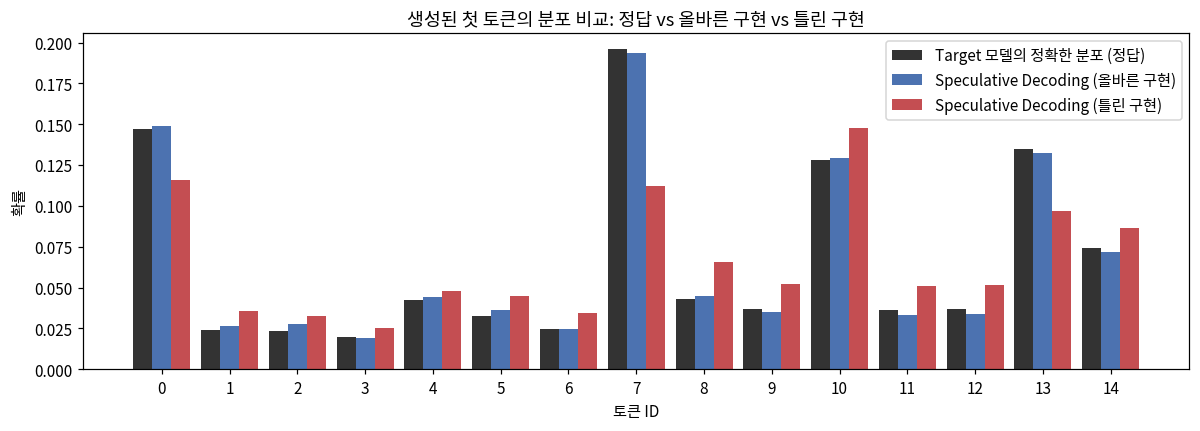

In [12]:
def speculative_decode_naive(draft_model, target_model, prompt_ids,
                              max_new_tokens=100, speculative_length=5, temperature=1.0):
    """speculative_decode()와 동일하지만, 거절 시 '잔여분포' 대신 target
    분포에서 그냥 재샘플링하는 (수학적으로 틀린) 버전입니다.
    -> 비교 실험 목적으로만 사용합니다. 실제로는 이 함수를 쓰면 안 됩니다."""
    tokens = prompt_ids.clone()
    total_draft, total_accepted, total_steps = 0, 0, 0

    while tokens.size(1) < prompt_ids.size(1) + max_new_tokens:
        total_steps += 1
        draft_tokens, draft_logprobs = [], []
        current = tokens
        for k in range(speculative_length):
            logprobs = draft_model.get_logprobs(current)
            next_logprob = logprobs[:, -1, :]
            probs = F.softmax(next_logprob / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            draft_tokens.append(next_token)
            draft_logprobs.append(next_logprob.gather(1, next_token))
            current = torch.cat([current, next_token], dim=1)
            total_draft += 1

        draft_seq = torch.cat([tokens] + draft_tokens, dim=1)
        target_logprobs = target_model.get_logprobs(draft_seq)

        n_accepted, rejected = 0, False
        for k in range(speculative_length):
            pos = tokens.size(1) - 1 + k
            target_prob = target_logprobs[:, pos, :].exp()
            draft_prob = draft_logprobs[k].exp()
            target_prob_of_token = target_prob.gather(1, draft_tokens[k])
            accept_ratio = (target_prob_of_token / (draft_prob + 1e-10)).clamp(max=1.0)

            if torch.rand(1).item() < accept_ratio.item():
                n_accepted += 1
                total_accepted += 1
            else:
                # <- 여기가 올바른 버전과 다른 부분: 잔여분포가 아니라
                # target_prob에서 곧바로 재샘플링합니다 (틀린 방법).
                resampled = torch.multinomial(target_prob, num_samples=1)
                accepted_tokens = torch.cat(draft_tokens[:n_accepted] + [resampled], dim=1)
                tokens = torch.cat([tokens, accepted_tokens], dim=1)
                rejected = True
                break

        if not rejected:
            bonus_pos = draft_seq.size(1) - 1
            bonus_probs = target_logprobs[:, bonus_pos, :].exp()
            bonus_token = torch.multinomial(bonus_probs, num_samples=1)
            tokens = torch.cat([tokens, torch.cat(draft_tokens + [bonus_token], dim=1)], dim=1)
            total_accepted += speculative_length

    return tokens, total_accepted / max(total_draft, 1), total_steps


# ── 실험 세팅 ──
torch.manual_seed(7)
small_vocab = 15
verify_draft = TinyLM(small_vocab, d_model=16, n_layers=1, nhead=2)
verify_target = TinyLM(small_vocab, d_model=32, n_layers=2, nhead=2)
verify_draft.eval()    # 추론 모드로 전환 (dropout 끄기) - 이게 없으면 같은 입력에도
verify_target.eval()   # 매번 다른 출력이 나와서 "무손실" 검증 자체가 무의미해집니다
verify_prompt = torch.randint(0, small_vocab, (1, 4))
prompt_len = verify_prompt.size(1)

# "정답": target 모델이 이 prompt 바로 뒤에 대해 실제로 갖고 있는 확률분포
with torch.no_grad():
    exact_target_dist = verify_target.get_logprobs(verify_prompt)[0, -1, :].exp()

N_TRIALS = 5000
counts_correct = torch.zeros(small_vocab)
counts_naive = torch.zeros(small_vocab)

print(f"{N_TRIALS}번 반복 실행 중... (작은 모델이라 CPU에서도 수십 초 내로 끝납니다)")
for i in range(N_TRIALS):
    out_correct, _, _ = speculative_decode(
        verify_draft, verify_target, verify_prompt,
        max_new_tokens=1, speculative_length=3)
    counts_correct[out_correct[0, prompt_len].item()] += 1

    out_naive, _, _ = speculative_decode_naive(
        verify_draft, verify_target, verify_prompt,
        max_new_tokens=1, speculative_length=3)
    counts_naive[out_naive[0, prompt_len].item()] += 1

empirical_correct = counts_correct / N_TRIALS
empirical_naive = counts_naive / N_TRIALS

# 분포 차이를 하나의 숫자로 요약: Total Variation Distance(총변동거리)
# 두 분포 사이의 "차이 총량"을 재는 지표로, 0이면 완전히 동일, 클수록 다릅니다.
# (계산: 각 토큰에서 확률 차이의 절댓값을 모두 더한 뒤 2로 나눔)
tvd_correct = 0.5 * (empirical_correct - exact_target_dist).abs().sum().item()
tvd_naive = 0.5 * (empirical_naive - exact_target_dist).abs().sum().item()

print(f"\n결과 (vocab 크기 = {small_vocab}, 시행 횟수 = {N_TRIALS})")
print(f"  [올바른 구현 (잔여분포 사용)]     Target과의 거리(TVD) = {tvd_correct:.4f}  <- 0에 가까울수록 정확")
print(f"  [틀린 구현   (target에서 재샘플)] Target과의 거리(TVD) = {tvd_naive:.4f}")
print(f"  (참고: 시행 횟수가 유한하기 때문에 올바른 구현도 표본오차 수준의 작은")
print(f"   TVD는 자연스럽게 남습니다. 중요한 건 naive 구현이 그 수준보다 훨씬")
print(f"   크다는 점입니다 - 이는 표본오차가 아니라 '구조적인 편향'입니다.)")

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(small_vocab)
width = 0.28
ax.bar(x - width, exact_target_dist.tolist(), width, label="Target 모델의 정확한 분포 (정답)", color="#333333")
ax.bar(x, empirical_correct.tolist(), width, label="Speculative Decoding (올바른 구현)", color="#4C72B0")
ax.bar(x + width, empirical_naive.tolist(), width, label="Speculative Decoding (틀린 구현)", color="#C44E52")
ax.set_xlabel("토큰 ID")
ax.set_ylabel("확률")
ax.set_title("생성된 첫 토큰의 분포 비교: 정답 vs 올바른 구현 vs 틀린 구현")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

print("\n막대그래프에서 '올바른 구현'(파란색)이 '정답'(회색)과 거의 겹치고,")
print("'틀린 구현'(빨간색)은 몇몇 토큰에서 눈에 띄게 어긋나는 것을 확인할 수 있습니다.")

## 정리 및 생각해볼 질문

**핵심 요약**
- Speculative Decoding은 작은 Draft 모델로 여러 토큰을 미리 제안하고,
  큰 Target 모델은 그 제안들을 **한 번의 병렬 forward**로 검증합니다.
- 수락 확률 `min(1, p_target/p_draft)`과, 거절 시 **잔여분포**에서
  재샘플링하는 규칙 덕분에 최종 출력 분포는 Target 모델 혼자
  생성한 것과 수학적으로 완전히 동일합니다 (무손실).
- 속도 향상의 크기는 **수락률**에 달려 있습니다. Draft와 Target이
  비슷하게 예측할수록(=Draft가 Target을 잘 흉내낼수록) 수락률이
  높아지고, Target 모델을 호출하는 횟수가 줄어듭니다.

**생각해볼 질문**

1. Draft 모델과 Target 모델이 완전히 동일한 모델이라면 수락률은 이론적으로 몇 %일까요?

   <details><summary>힌트 보기</summary>
   p(x) = q(x)이므로 모든 토큰에서 accept_ratio = min(1, p/q) = 1이
   됩니다. 즉 이론적으로 수락률 100%가 되어 거절이 전혀 발생하지
   않습니다. (실제로는 이 경우 Draft를 따로 쓸 이유가 없으므로,
   Target 모델 하나로 자기회귀 디코딩을 하는 것과 사실상 같습니다.)
   </details>

2. K(speculative_length)를 아주 크게 늘리면 어떤 장단점이 생길까요?

   <details><summary>힌트 보기</summary>
   장점: 한 라운드에서 채택될 수 있는 토큰 수의 상한이 늘어납니다
   (운이 좋으면 더 많은 토큰을 한 번에 얻습니다).
   단점: 앞쪽 제안이 뒤쪽 제안보다 먼저 검사되고, 한 번이라도 거절되면
   그 라운드의 나머지 제안은 전부 버려집니다. K가 클수록 "뒤쪽까지
   전부 수락될" 확률은 점점 낮아지므로, Draft 모델을 K번 순차 호출한
   비용 대비 실제로 얻는 토큰 수가 기대만큼 늘지 않을 수 있습니다.
   </details>

3. Draft 모델을 어떻게 만들면(어떻게 학습시키면) 수락률을 높일 수 있을까요?

   <details><summary>힌트 보기</summary>
   Target 모델과 비슷한 데이터/방식으로 Draft를 학습시키거나
   (distillation), Target 모델 자체를 경량화해서 Draft로 쓰면 두
   모델의 예측 분포가 비슷해져 수락률이 올라갑니다. 실제로 Medusa,
   EAGLE 같은 후속 연구들이 이런 방향의 개선을 시도합니다.
   </details>

**실제로 이 기법은 어디에 쓰일까?**

vLLM, TensorRT-LLM 같은 실제 LLM 서빙 엔진과 Medusa/EAGLE 같은 후속
연구들이 Speculative Decoding 아이디어를 다양한 방식으로 확장해서
사용하고 있습니다. 기본 원리는 오늘 실습한 것과 동일합니다:
**작은 비용으로 여러 후보를 미리 만들고, 정확한 모델이 한 번에
검증한다.**